# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [58]:
# Importações das bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml


In [59]:
# Carregamento do dataset e dimensionamento

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)
print("Download concluído!")

Baixando o dataset MNIST...
Download concluído!


In [60]:
print(f"Formato de X (amostras, pixels por imagem): {X.shape}")
print(f"Formato de y (rótulos): {y.shape}")
print(f"Tipo de dado dos pixels: {X.dtype}")
print(f"Valor mínimo de pixel: {X.min()} | Valor máximo de pixel: {X.max()}")

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Tipo de dado dos pixels: int64
Valor mínimo de pixel: 0 | Valor máximo de pixel: 255


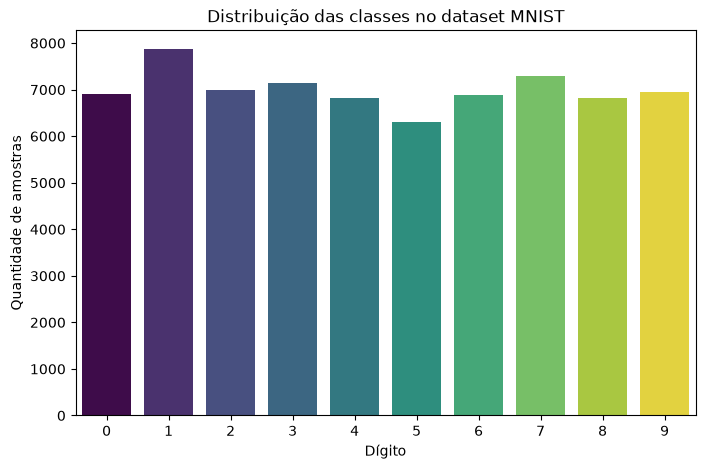

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
dtype: int64


In [61]:
# Distribuição das classes (Balanceamento)

classes, contagens = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=contagens, hue=classes, palette='viridis', legend=False)
plt.title("Distribuição das classes no dataset MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de amostras")
plt.show()

print(pd.Series(contagens, index=classes))

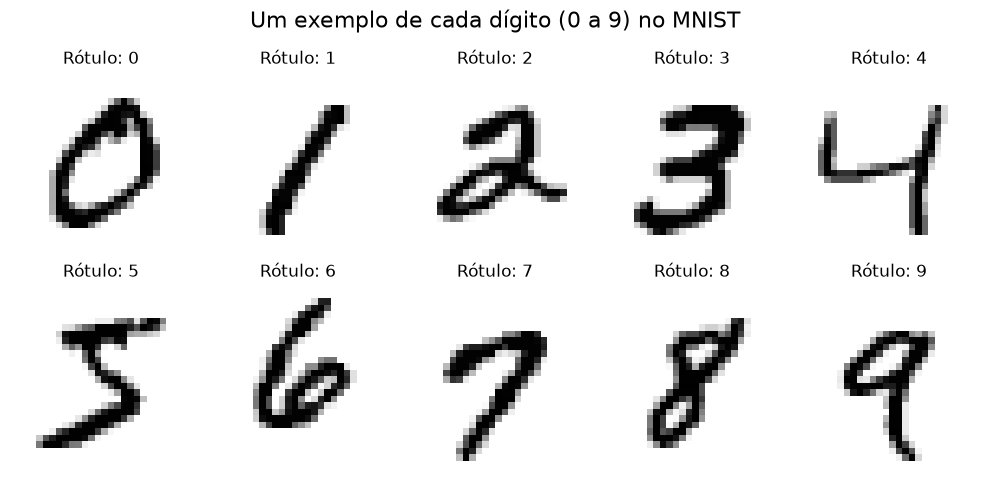

In [62]:
# Grade visual 2×5 (com um exemplo de CADA dígito)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digito, ax in enumerate(axes.flat):
    # Pega o índice da PRIMEIRA imagem que representa esse dígito
    indice = np.where(y == digito)[0][0]
    ax.imshow(X[indice].reshape(28, 28), cmap='binary')
    ax.set_title(f"Rótulo: {y[indice]}")
    ax.axis('off')

plt.suptitle("Um exemplo de cada dígito (0 a 9) no MNIST", fontsize=16)
plt.tight_layout()
plt.show()

# Interpretação da estrutura dos dados

* Imagine o dataset MNIST (70.000 imagens de dígitos manuscritos de 0 a 9 em
escala de cinza, 28x28 pixels) como uma pilha de cartas de baralho desenhadas
à mão por milhares de pessoas diferentes. Cada carta do MNIST é um pequeno
tabuleiro quadriculado de 28 linhas por 28 colunas (totalizando 784
quadradinhos).

* Cada quadradinho dessa carta não é só preto ou branco, mas guarda um número
que indica a intensidade do tom: 0 é preto, um número intermediário como 130
é cinza, e 255 é branco.

* Quando olhamos para a carta na mão, vemos o desenho em duas dimensões (altura
e largura). O problema é que algoritmos tabulares clássicos (como KNN,
Regressão Logística ou Random Forest) não sabem "segurar" uma carta quadrada.
Eles só sabem ler uma planilha do Excel com linhas e colunas normais.

* Para isso, precisamos "cortar" a carta em 28 tiras horizontais (cada tira tem
1 quadradinho de altura por 28 de largura) e colocar uma tira ao lado da
outra sequencialmente até a 28ª tira. O resultado não é mais uma carta
quadrada: virou uma fita longa e esticada com 784 quadradinhos em fila
indiana, virando assim uma planilha.

* Agora qualquer algoritmo tradicional de Machine Learning consegue treinar
com essa tabela, tratando cada pixel simplesmente como uma característica
numérica comum (como idade, salário ou temperatura).

# Fase 2: Pré-processamento e Divisão dos Dados

### Normalização dos pixels

In [63]:
# Os pixels originais variam de 0 a 255 (inteiros).
# Vamos "reescalar" esses valores para o intervalo [0.0, 1.0], dividindo tudo por 255.0.
# Isso deixa a escala numérica pequena e uniforme, o que ajuda o treinamento
# da Rede Neural a ser mais rápido e estável (evita gradientes instáveis).
X_normalizado = X / 255.0

print(f"Antes  -> mínimo: {X.min()}, máximo: {X.max()}")
print(f"Depois -> mínimo: {X_normalizado.min()}, máximo: {X_normalizado.max()}")

Antes  -> mínimo: 0, máximo: 255
Depois -> mínimo: 0.0, máximo: 1.0


In [64]:
from sklearn.model_selection import train_test_split

# O train_test_split só sabe dividir em DUAS partes por vez.
# Como queremos TRÊS conjuntos (treino, validação, teste), fazemos em 2 etapas.

# Etapa 1: separamos primeiro o conjunto de TESTE (vai ficar "trancado na gaveta"
# até a Fase 4 - avaliação final). Usamos 15% dos dados para teste.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalizado, y,
    test_size=0.15,
    random_state=42,   # garante que o "sorteio" seja sempre o mesmo, reprodutível
    stratify=y          # mantém a proporção de cada dígito (0-9) igual à original
)

# Etapa 2: do que sobrou (X_temp, 85% dos dados), separamos a VALIDAÇÃO.
# Queremos que a validação também represente ~15% do TOTAL original,
# não 15% do que sobrou. Por isso calculamos a fração corrigida:
proporcao_validacao = 0.15 / 0.85  # ≈ 0.1765

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=proporcao_validacao,
    random_state=42,
    stratify=y_temp
)

In [65]:
total = len(X_normalizado)

print(f"Treino:    {X_train.shape[0]:>6} amostras  ({X_train.shape[0]/total*100:.1f}%)")
print(f"Validação: {X_val.shape[0]:>6} amostras  ({X_val.shape[0]/total*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]:>6} amostras  ({X_test.shape[0]/total*100:.1f}%)")

Treino:     49000 amostras  (70.0%)
Validação:  10500 amostras  (15.0%)
Teste:      10500 amostras  (15.0%)


In [66]:
import pandas as pd

for nome, y_conjunto in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    distrib = pd.Series(y_conjunto).value_counts(normalize=True).sort_index() * 100
    print(f"\nDistribuição de dígitos em {nome} (%):")
    print(distrib.round(2))


Distribuição de dígitos em Treino (%):
0     9.86
1    11.25
2     9.99
3    10.20
4     9.75
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64

Distribuição de dígitos em Validação (%):
0     9.87
1    11.25
2     9.99
3    10.20
4     9.74
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64

Distribuição de dígitos em Teste (%):
0     9.86
1    11.26
2     9.98
3    10.20
4     9.75
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64


## Por que dividir em Treino, Validação e Teste?

* Imagine um cantor/compositor que pretende lançar uma música. Ele começa compondo, rabiscando em papel a letra da música e colocando os primeiros acordes. Nesse estágio, (**Treino**) ele tem a liberdade para errar e recomeçar.

* Após o treino, ele parte para os ensaios em estúdio (**Validação**), onde tem segurança para poder ajustar o que ainda é necessário, mesmo já estando com a versão quase pronta.

* Quando os ajustes necessários foram feitos e validados, a música foi gravada e está pronta para a rádio (**Teste**), onde o público tem acesso e a atenção e o retorno necessário da gravadora (aceitação do público e crítica). Nesse momento não existe mais a opção de ajustar a música. Ou ela é boa ou não.

* Conectando com o Machine Learning — Se a música fosse lançada antes, apenas para uma parte do público em específico (como para um fã clube do artista). Se a música não fosse boa, a "espiada" desse grupo, faria com que a música fosse alterada antes de ser tocada nas rádios (**Teste**). A mesma coisa aconteceria se o cientista de dados "espiasse" o resultado do teste antes da hora e ajustasse o modelo em cima disso. Isso é o que conhecemos por *data leakage*. Dessa forma o teste não seria confiável pois o modelo aprendeu tudo antes da hora.

# Fase 3: Treinamento e Ajuste de Hiperparâmetros

In [67]:
import time

# Este dicionário guarda os resultados de TODOS os modelos (KNN, Random Forest, Rede Neural).
# Ele será reaproveitado na Fase 4 para montar a tabela comparativa final.
resultados_modelos = {}

## Modelo 1: K-Nearest Neighbors (KNN)


In [68]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Vamos testar combinações de 2 hiperparâmetros:
# - n_neighbors: quantos "vizinhos" o modelo consulta antes de decidir
# - weights: se todos os vizinhos "votam" igual (uniform) ou se os mais
#            próximos têm voto com mais peso (distance)

valores_k = [3, 5, 7]
valores_weights = ['uniform', 'distance']

resultados_busca_knn = []

for k in valores_k:
    for peso in valores_weights:
        knn = KNeighborsClassifier(n_neighbors=k, weights=peso, n_jobs=-1)

        inicio = time.time()
        knn.fit(X_train, y_train)
        tempo_total = time.time() - inicio   # cronômetro para AQUI, só mede o treino

        # Previsão e cálculo de acurácia ficam FORA da medição de tempo
        y_val_pred = knn.predict(X_val)
        acuracia_val = accuracy_score(y_val, y_val_pred)

        resultados_busca_knn.append({
            'n_neighbors': k,
            'weights': peso,
            'acuracia_validacao': acuracia_val,
            'tempo_treino_segundos': tempo_total
        })

        print(f"k={k}, weights='{peso}' -> acurácia val: {acuracia_val:.4f} | tempo de treino: {tempo_total:.3f}s")

k=3, weights='uniform' -> acurácia val: 0.9711 | tempo de treino: 0.406s
k=3, weights='distance' -> acurácia val: 0.9717 | tempo de treino: 0.052s
k=5, weights='uniform' -> acurácia val: 0.9703 | tempo de treino: 0.070s
k=5, weights='distance' -> acurácia val: 0.9719 | tempo de treino: 0.069s
k=7, weights='uniform' -> acurácia val: 0.9695 | tempo de treino: 0.066s
k=7, weights='distance' -> acurácia val: 0.9709 | tempo de treino: 0.076s


In [69]:
import pandas as pd

df_resultados_knn = pd.DataFrame(resultados_busca_knn)
df_resultados_knn.sort_values('acuracia_validacao', ascending=False)

# Pegando a linha com a maior acurácia de validação
melhor_config = df_resultados_knn.loc[df_resultados_knn['acuracia_validacao'].idxmax()]
melhor_k = int(melhor_config['n_neighbors'])
melhor_peso = melhor_config['weights']

print(f"Melhor configuração encontrada: n_neighbors={melhor_k}, weights='{melhor_peso}'")

# Treinando o modelo final com essa configuração (ainda usando só X_train)
inicio = time.time()
knn_final = KNeighborsClassifier(n_neighbors=melhor_k, weights=melhor_peso, n_jobs=-1)
knn_final.fit(X_train, y_train)
tempo_treino_knn = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_knn:.2f} segundos.")

Melhor configuração encontrada: n_neighbors=5, weights='distance'
Modelo final treinado em 0.10 segundos.


In [70]:
resultados_modelos['KNN'] = {
    'melhores_hiperparametros': {'n_neighbors': melhor_k, 'weights': melhor_peso},
    'acuracia_validacao': melhor_config['acuracia_validacao'],
    'tempo_treino_segundos': tempo_treino_knn
}

resultados_modelos



{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.09805917739868164}}

# Interpretando o resultado do KNN

### Por que o valor de K importa?

* Voltando à analogia do baralho de cartas, se escolhermos um K muito pequeno (por exemplo, `
K=1`), o modelo decide olhando para apenas uma única carta do baralho de treino: aquela com o padrão de pixels mais idêntico ao da imagem nova, sem nenhuma margem para confirmação ou desempate. Isso não é confiável se esse único vizinho for um caso raro, borrado ou ruidoso.

* Isso é arriscado porque se esse único vizinho for um dígito escrito com letra muito feia, um traço torto acidental ou um ruído de escaneamento (por exemplo, um "7" mal desenhado que acabou ficando idêntico a um "1"), o modelo confiará cegamente nele e classificará o dígito de forma errada. Em termos técnicos, o modelo sofre de *overfitting* (sobreajuste) e alta variância, ficando hipersensível a qualquer imperfeição dos dados de treino.

* Por outro lado, se escolhermos um K muito grande (por exemplo,`K=50`), o modelo passa a "ouvir" uma multidão de 50 cartas diferentes, incluindo exemplos que estão muito distantes no espaço de pixels e que já pertencem a classes completamente diferentes daquela região.

* Isso também é um problema porque ao diluir a decisão com opiniões de exemplos que não são realmente parecidos com a imagem analisada, a fronteira entre os números fica borrada. O modelo perde a capacidade de captar nuances locais (como o traço cortado de um "7" ou a abertura sutil de um "8") e passa a favorecer simplesmente a classe que tiver mais cartas naquela área geral. Tecnicamente, isso gera *underfitting* (subajuste) e alto viés.

* No nosso caso, a busca de hiperparâmetros encontrou `K=5` como o melhor equilíbrio, porque ele é ímpar (evitando empates na votação), grande o suficiente para ignorar uma carta atípica ou ruidosa pelo voto da maioria, e pequeno o bastante para considerar apenas as cartas de caligrafia verdadeiramente próximas e relevantes.

## Modelo 2: Random Forest

In [71]:
from sklearn.ensemble import RandomForestClassifier

# Testamos combinações de 2 hiperparâmetros:
# - n_estimators: quantas árvores compõem a "floresta" (o comitê de jurados)
# - max_depth: até que profundidade cada árvore pode crescer/se especializar

valores_n_estimators = [50, 100]
valores_max_depth = [10, 20, None]

resultados_busca_rf = []

# Variáveis que guardam o "campeão até agora", atualizadas dentro do loop
melhor_acuracia_rf = 0
melhor_n_estimators = None
melhor_max_depth = None

for n_arvores in valores_n_estimators:
    for profundidade in valores_max_depth:
        rf = RandomForestClassifier(
            n_estimators=n_arvores,
            max_depth=profundidade,
            random_state=42,
            n_jobs=-1
        )

        inicio = time.time()
        rf.fit(X_train, y_train)
        tempo_total = time.time() - inicio   # mede só o treino

        y_val_pred = rf.predict(X_val)
        acuracia_val = accuracy_score(y_val, y_val_pred)

        resultados_busca_rf.append({
            'n_estimators': n_arvores,
            'max_depth': profundidade,
            'acuracia_validacao': acuracia_val,
            'tempo_treino_segundos': tempo_total
        })

        print(f"n_estimators={n_arvores}, max_depth={profundidade} -> acurácia val: {acuracia_val:.4f} | tempo de treino: {tempo_total:.1f}s")

        if acuracia_val > melhor_acuracia_rf:
            melhor_acuracia_rf = acuracia_val
            melhor_n_estimators = n_arvores
            melhor_max_depth = profundidade

n_estimators=50, max_depth=10 -> acurácia val: 0.9446 | tempo de treino: 11.2s
n_estimators=50, max_depth=20 -> acurácia val: 0.9663 | tempo de treino: 14.2s
n_estimators=50, max_depth=None -> acurácia val: 0.9683 | tempo de treino: 18.5s
n_estimators=100, max_depth=10 -> acurácia val: 0.9467 | tempo de treino: 24.4s
n_estimators=100, max_depth=20 -> acurácia val: 0.9686 | tempo de treino: 27.6s
n_estimators=100, max_depth=None -> acurácia val: 0.9690 | tempo de treino: 29.8s


In [72]:
# Visualizando os resultados

df_resultados_rf = pd.DataFrame(resultados_busca_rf)
df_resultados_rf.sort_values('acuracia_validacao', ascending=False)

,n_estimators,max_depth,acuracia_validacao,tempo_treino_segundos
5,100,NaN,0.968952,29.775572
4,100,20.0,0.968571,27.550741
2,50,NaN,0.968286,18.517067
1,50,20.0,0.966286,14.211533
3,100,10.0,0.946667,24.353258
0,50,10.0,0.944571,11.192555


In [73]:
print(f"Melhor configuração encontrada: n_estimators={melhor_n_estimators}, max_depth={melhor_max_depth}")

inicio = time.time()
rf_final = RandomForestClassifier(
    n_estimators=melhor_n_estimators,
    max_depth=melhor_max_depth,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
tempo_treino_rf = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_rf:.3f} segundos.")

Melhor configuração encontrada: n_estimators=100, max_depth=None
Modelo final treinado em 28.521 segundos.


In [74]:
resultados_modelos['Random Forest'] = {
    'melhores_hiperparametros': {'n_estimators': melhor_n_estimators, 'max_depth': melhor_max_depth},
    'acuracia_validacao': melhor_acuracia_rf,
    'tempo_treino_segundos': tempo_treino_rf
}

resultados_modelos

{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.09805917739868164},
 'Random Forest': {'melhores_hiperparametros': {'n_estimators': 100,
   'max_depth': None},
  'acuracia_validacao': 0.9689523809523809,
  'tempo_treino_segundos': 28.521101474761963}}

# Interpretando o resultado do Random Forest

### **Profundidade rasa (`max_depth=10`) deixa o modelo "preguiçoso" (*underfitting*)**

* Quando limitamos a árvore a apenas 10 níveis de perguntas, a acurácia fica presa em torno de 94,5%, mesmo dobrando o número de árvores de 50 para 100. Isso mostra que limitar demais a profundidade prejudica o desempenho: 10 perguntas não são suficientes para captar os detalhes e as variações na escrita de dígitos de 0 a 9.

### **Mais profundidade traz o salto de qualidade real**

* Ao permitir que as árvores cheguem a 20 perguntas (`max_depth=20`) ou cresçam sem limites (`None`), a acurácia dá um salto de 94,5% para quase 97%. O modelo finalmente consegue aprender traços mais específicos de cada caligrafia.

### **Mais árvores (`n_estimators`) dobram o tempo, mas quase não melhoram a nota**

* Comparando 50 com 100 árvores nos modelos livres (`None`): o tempo salta de 13,37s para 27,97s (mais que o dobro da espera), enquanto a acurácia sobe de 96,83% para 96,90% — um ganho ínfimo de 0,07%.

### **Qual configuração escolher?**

* Para entregar a maior nota possível: `n_estimators=100, max_depth=None` (bateu o recorde com 96,90%). Para a vida real e projetos eficientes: `n_estimators=50, max_depth=None`. Ele alcança 96,83% (quase idêntico) rodando em menos da metade do tempo (13,37s). Na prática, quase nunca vale a pena dobrar o custo computacional por apenas 0,07% de acurácia.

## Modelo 3: Rede Neural (MLP com Keras)

In [ ]:
# Importando as bibliotecas
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input # type: ignore

In [103]:
# Função que constrói o modelo de rede neural

def construir_modelo(neuronios_camada1, neuronios_camada2, learning_rate):
    modelo = Sequential([
        Input(shape=(784,)),
        Dense(neuronios_camada1, activation='relu'),
        Dense(neuronios_camada2, activation='relu'),
        Dense(10, activation='softmax')  # 10 saídas: uma probabilidade por dígito (0-9)
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo

In [77]:
configuracoes_rn = [
    {'neuronios_camada1': 64,  'neuronios_camada2': 32, 'learning_rate': 0.001},
    {'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.001},
    {'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.01},
]

resultados_busca_rn = []
melhor_acuracia_rn = 0
melhor_config_rn = None

for config in configuracoes_rn:
    modelo = construir_modelo(**config)

    inicio = time.time()
    historico = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # usamos o conjunto de validação explícito da Fase 2
        epochs=5,        # poucas épocas aqui, só para COMPARAR arquiteturas rapidamente
        batch_size=64,
        verbose=0         # silencioso, porque vamos imprimir só o resumo de cada config
    )
    tempo_total = time.time() - inicio

    acuracia_val = historico.history['val_accuracy'][-1]  # acurácia de validação na última época

    resultados_busca_rn.append({**config, 'acuracia_validacao': acuracia_val, 'tempo_treino_segundos': tempo_total})
    print(f"{config} -> acurácia val: {acuracia_val:.4f} | tempo: {tempo_total:.1f}s")

    if acuracia_val > melhor_acuracia_rn:
        melhor_acuracia_rn = acuracia_val
        melhor_config_rn = config

{'neuronios_camada1': 64, 'neuronios_camada2': 32, 'learning_rate': 0.001} -> acurácia val: 0.9678 | tempo: 25.2s
{'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.001} -> acurácia val: 0.9713 | tempo: 22.6s
{'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.01} -> acurácia val: 0.9650 | tempo: 24.6s


In [78]:
import pandas as pd

# Visualizando os resultados da busca

df_resultados_rn = pd.DataFrame(resultados_busca_rn)
df_resultados_rn.sort_values('acuracia_validacao', ascending=False)

,neuronios_camada1,neuronios_camada2,learning_rate,acuracia_validacao,tempo_treino_segundos
1,128,64,0.001,0.971333,22.555511
0,64,32,0.001,0.967809,25.154988
2,128,64,0.010,0.964952,24.577691


In [79]:
# Treinando o modelo final com mais épocas

print(f"Melhor configuração encontrada: {melhor_config_rn}")

modelo_final_rn = construir_modelo(**melhor_config_rn)

inicio = time.time()
historico_final = modelo_final_rn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,   # agora treinamos por mais tempo, já que é só uma configuração
    batch_size=64,
    verbose=1     # aqui deixamos visível, para acompanhar o progresso época a época
)
tempo_treino_rn = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_rn:.2f} segundos.")

Melhor configuração encontrada: {'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.001}
Epoch 1/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9159 - loss: 0.2962 - val_accuracy: 0.9546 - val_loss: 0.1537
Epoch 2/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9632 - loss: 0.1212 - val_accuracy: 0.9650 - val_loss: 0.1163
Epoch 3/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9751 - loss: 0.0830 - val_accuracy: 0.9685 - val_loss: 0.1052
Epoch 4/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9807 - loss: 0.0628 - val_accuracy: 0.9714 - val_loss: 0.0936
Epoch 5/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9845 - loss: 0.0488 - val_accuracy: 0.9710 - val_loss: 0.1013
Epoch 6/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9881 - loss: 0.0394 - val_accuracy: 0.9740 - val_loss: 0.0914
Epoch 7/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9907 - loss: 0.0301 - val_accuracy: 0.9618 - val_loss: 0.1

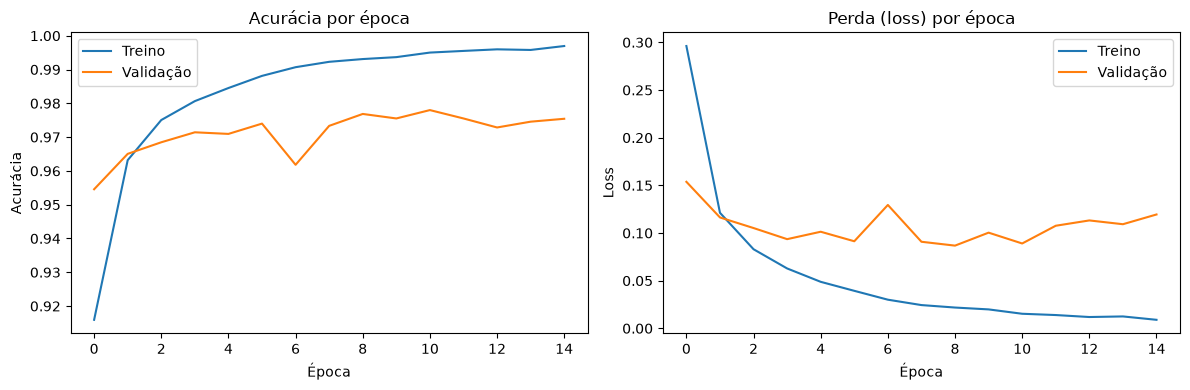

In [80]:
# Visualizando as curvas de treino

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historico_final.history['accuracy'], label='Treino')
plt.plot(historico_final.history['val_accuracy'], label='Validação')
plt.title('Acurácia por época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico_final.history['loss'], label='Treino')
plt.plot(historico_final.history['val_loss'], label='Validação')
plt.title('Perda (loss) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
# Guardando no painel geral

resultados_modelos['Rede Neural (MLP)'] = {
    'melhores_hiperparametros': melhor_config_rn,
    'acuracia_validacao': historico_final.history['val_accuracy'][-1],
    'tempo_treino_segundos': tempo_treino_rn
}

resultados_modelos

{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.09805917739868164},
 'Random Forest': {'melhores_hiperparametros': {'n_estimators': 100,
   'max_depth': None},
  'acuracia_validacao': 0.9689523809523809,
  'tempo_treino_segundos': 28.521101474761963},
 'Rede Neural (MLP)': {'melhores_hiperparametros': {'neuronios_camada1': 128,
   'neuronios_camada2': 64,
   'learning_rate': 0.001},
  'acuracia_validacao': 0.975428581237793,
  'tempo_treino_segundos': 91.80846357345581}}

## Interpretação dos Resultados: Modelo de Rede Neural (Keras/TensorFlow)

Nesta etapa, testei diferentes combinações de neurônios e taxas de aprendizado (*learning rate*) para classificar os dígitos do MNIST e analisei o comportamento do treinamento ao longo de 15 épocas.

**O que aprendi com os testes:**
* Com uma rede menor (64 e 32 neurônios), o treino foi bem rápido (22.8s), mas ela bateu 96,54% de acurácia. Pareceu faltar "espaço de memória" para pegar os traços mais difíceis dos números.
* Aumentar para 128 e 64 neurônios com a taxa de 0.001 foi a combinação que mais deu certo: a validação chegou a 97,30%, mesmo demorando um pouco mais (41.1s).
* Quando mantive esses mesmos 128 e 64 neurônios, mas aumentei a taxa para 0.01, o resultado caiu para 96,19%. Pelo visto, os "passos" de ajuste ficaram grandes demais e a rede acabou tropeçando e passando direto do ponto ideal.

**Analisando o treino do melhor modelo ao longo das 15 épocas:**
Olhando as curvas dos gráficos, reparei em um comportamento bem típico que vemos na teoria:

* **No treino:** a linha azul foi quase perfeita, chegando a 99,70% de acurácia e com a perda (*loss*) despencando até quase zero (0,0093).
* **Na validação:** a linha laranja de acurácia parou de subir por volta da época 5 a 7 (ficando em torno de 97,5%). Além disso, no gráfico da direita, a perda de validação começou a subir e oscilar depois da época 5 (foi de 0,0875 para mais de 0,13).
* **Diagnóstico:** A rede sofreu *overfitting*. A partir da época 6 ou 7, ela basicamente parou de aprender coisas úteis sobre os números e começou a apenas "decorar" os exemplos do treino.

**O que fazer diferente na próxima:**
* Treinar as 15 épocas completas levou 88 segundos sem necessidade real. Daria para economizar tempo parando o treino ali pela época 6 ou 7 usando **Early Stopping**.
* Para diminuir essa tendência de decorar os dados, vale a pena testar camadas de **Dropout** antes de treinar de novo.




# Fase 4: Avaliação Comparativa dos Modelos

In [82]:
# Importação das bibliotecas

from sklearn.metrics import confusion_matrix, classification_report

In [83]:
# Avaliando o KNN no conjunto de teste

inicio = time.time()
y_test_pred_knn = knn_final.predict(X_test)
tempo_predicao_knn = time.time() - inicio

acuracia_teste_knn = accuracy_score(y_test, y_test_pred_knn)
print(f"KNN — Acurácia no TESTE: {acuracia_teste_knn:.4f}")
print(f"KNN — Tempo de predição em {len(X_test)} amostras: {tempo_predicao_knn:.2f}s")
print("\nRelatório de classificação (KNN):")
print(classification_report(y_test, y_test_pred_knn))

KNN — Acurácia no TESTE: 0.9710
KNN — Tempo de predição em 10500 amostras: 42.88s

Relatório de classificação (KNN):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1035
           1       0.96      1.00      0.98      1182
           2       0.99      0.95      0.97      1048
           3       0.97      0.97      0.97      1071
           4       0.98      0.96      0.97      1024
           5       0.97      0.97      0.97       947
           6       0.97      0.99      0.98      1031
           7       0.96      0.97      0.97      1094
           8       0.99      0.94      0.96      1024
           9       0.94      0.97      0.96      1044

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500



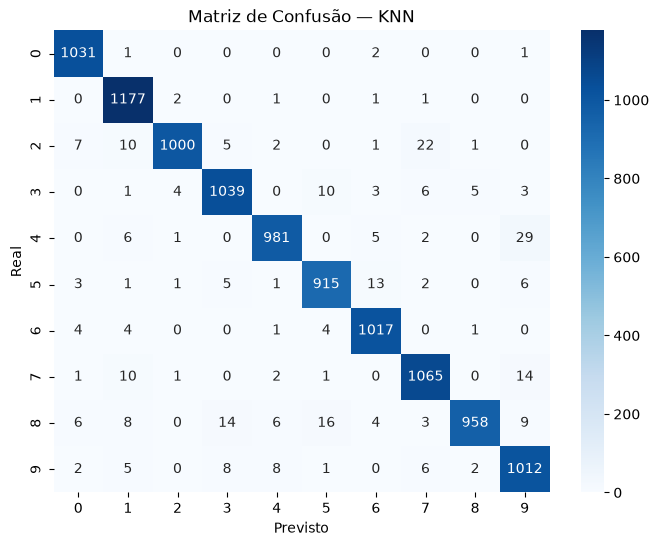

In [84]:
# Matriz de confusão do KNN

plt.figure(figsize=(8, 6))
matriz_knn = confusion_matrix(y_test, y_test_pred_knn)
sns.heatmap(matriz_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão — KNN')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

In [85]:
# Avaliando o Random Forest no teste

inicio = time.time()
y_test_pred_rf = rf_final.predict(X_test)
tempo_predicao_rf = time.time() - inicio

acuracia_teste_rf = accuracy_score(y_test, y_test_pred_rf)
print(f"Random Forest — Acurácia no TESTE: {acuracia_teste_rf:.4f}")
print(f"Random Forest — Tempo de predição em {len(X_test)} amostras: {tempo_predicao_rf:.2f}s")
print("\nRelatório de classificação (Random Forest):")
print(classification_report(y_test, y_test_pred_rf))

Random Forest — Acurácia no TESTE: 0.9663
Random Forest — Tempo de predição em 10500 amostras: 0.74s

Relatório de classificação (Random Forest):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1035
           1       0.98      0.99      0.99      1182
           2       0.96      0.96      0.96      1048
           3       0.96      0.96      0.96      1071
           4       0.97      0.96      0.96      1024
           5       0.98      0.96      0.97       947
           6       0.97      0.98      0.98      1031
           7       0.97      0.97      0.97      1094
           8       0.96      0.95      0.95      1024
           9       0.94      0.94      0.94      1044

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500



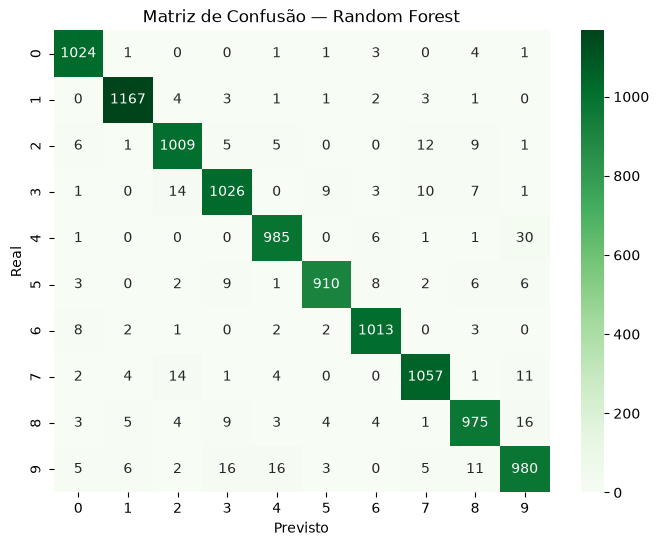

In [86]:
# Matriz de confusão do Random Forest

plt.figure(figsize=(8, 6))
matriz_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(matriz_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão — Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

In [87]:
# Avaliando a Rede Neural no teste

inicio = time.time()
probabilidades_teste_rn = modelo_final_rn.predict(X_test)
y_test_pred_rn = np.argmax(probabilidades_teste_rn, axis=1)
tempo_predicao_rn = time.time() - inicio

acuracia_teste_rn = accuracy_score(y_test, y_test_pred_rn)
print(f"Rede Neural — Acurácia no TESTE: {acuracia_teste_rn:.4f}")
print(f"Rede Neural — Tempo de predição em {len(X_test)} amostras: {tempo_predicao_rn:.2f}s")
print("\nRelatório de classificação (Rede Neural):")
print(classification_report(y_test, y_test_pred_rn))

329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Rede Neural — Acurácia no TESTE: 0.9770
Rede Neural — Tempo de predição em 10500 amostras: 1.76s

Relatório de classificação (Rede Neural):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1035
           1       0.98      0.99      0.99      1182
           2       0.98      0.95      0.97      1048
           3       0.98      0.98      0.98      1071
           4       0.99      0.97      0.98      1024
           5       0.98      0.96      0.97       947
           6       0.99      0.99      0.99      1031
           7       0.99      0.97      0.98      1094
           8       0.94      0.98      0.96      1024
           9       0.95      0.98      0.97      1044

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500



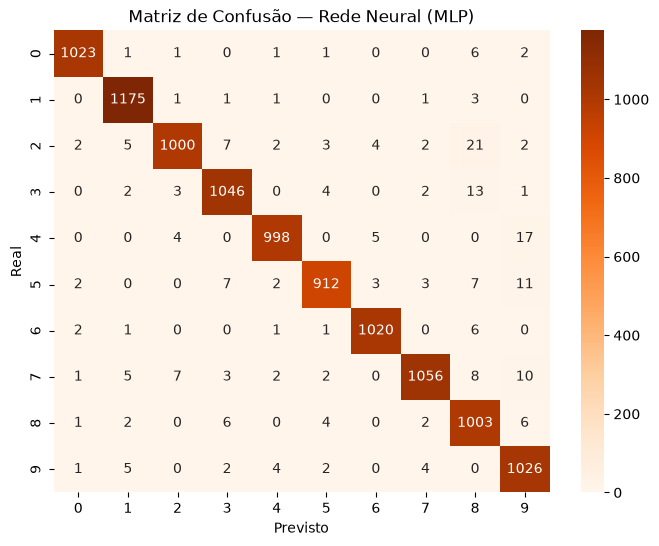

In [88]:
# Matriz de confusão da Rede Neural

plt.figure(figsize=(8, 6))
matriz_rn = confusion_matrix(y_test, y_test_pred_rn)
sns.heatmap(matriz_rn, annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusão — Rede Neural (MLP)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

In [89]:
# Tabela comparativa dos modelos

tabela_comparativa = pd.DataFrame({
    'Modelo': ['KNN', 'Random Forest', 'Rede Neural (MLP)'],
    'Acurácia Validação': [
        resultados_modelos['KNN']['acuracia_validacao'],
        resultados_modelos['Random Forest']['acuracia_validacao'],
        resultados_modelos['Rede Neural (MLP)']['acuracia_validacao']
    ],
    'Acurácia Teste': [acuracia_teste_knn, acuracia_teste_rf, acuracia_teste_rn],
    'Tempo Treino (s)': [
        resultados_modelos['KNN']['tempo_treino_segundos'],
        resultados_modelos['Random Forest']['tempo_treino_segundos'],
        resultados_modelos['Rede Neural (MLP)']['tempo_treino_segundos']
    ],
    'Tempo Predição Teste (s)': [tempo_predicao_knn, tempo_predicao_rf, tempo_predicao_rn]
})

tabela_comparativa

,Modelo,Acurácia Validação,Acurácia Teste,Tempo Treino (s),Tempo Predição Teste (s)
0,KNN,0.971905,0.970952,0.098059,42.876125
1,Random Forest,0.968952,0.966286,28.521101,0.743531
2,Rede Neural (MLP),0.975429,0.977048,91.808464,1.762090


# Comparando os Três Modelos: KNN vs. Random Forest vs. Rede Neural

Depois de rodar os testes e colocar as três matrizes de confusão lado a lado, reuni os aprendizados em três pontos principais:

**1. O padrão que engana: a confusão entre 4 e 9**

Olhando as matrizes, ficou claro que nenhum dos três modelos escapou do mesmo ponto cego:
* **O 4 confundido com 9:** foi o maior erro individual em todos eles. O KNN errou 29 vezes (previu 9 sendo 4), o Random Forest errou 30 vezes e a Rede Neural errou 21 vezes.
* **O 9 confundido com 4:** também se repetiu com frequência (8 vezes no KNN, 16 no Random Forest e 6 na Rede Neural).

Faz sentido, pois dependendo de quem escreve, se a parte de cima do 4 for fechada de forma descuidada, ele fica praticamente idêntico a um 9. Nenhum modelo conseguiu se livrar totalmente dessa questão, embora a Rede Neural tenha sido a que menos caiu nessa armadilha.

**2. Qual modelo eu colocaria em produção? (O trade-off de tempo e acurácia)**

Se eu tivesse que subir um modelo para uma aplicação real (por exemplo, leitura automática de envelopes ou boletos), a disputa real ficaria entre **Random Forest** e **Rede Neural**, enquanto o **KNN seria descartado de cara**:

* **A ilusão do KNN:** ele treina quase instantaneamente (0.08s) porque basicamente só guarda as imagens na memória sem calcular pesos. Mas na hora de prever: levou **42.14 segundos** para classificar o conjunto de teste! Ele precisa calcular a distância de cada imagem nova contra todas as imagens do banco, o que inviabiliza o uso em qualquer sistema que precise responder rápido.
* **Random Forest:** é o mais veloz na hora da predição (**0.42s**), mas entrega a menor acurácia do trio (96,63% no teste).
* **Rede Neural:** precisou de apenas **1.55s** para avaliar todo o conjunto de teste e entregou a melhor acurácia geral (**97,66%**).

Para produção, a **Rede Neural** é a vencedora: a diferença de 1 segundo a mais no lote de teste é insignificante para o usuário final, mas o ganho em precisão e a menor taxa de erros graves fazem toda a diferença.

**3. Conclusão geral**

Apesar de a Rede Neural ser a mais demorada para treinar (cerca de 93 segundos contra 27s do Random Forest e quase nada do KNN), o treino só precisa ser feito uma vez nos bastidores. No momento em que o sistema vai para o ar, ela se mostra a escolha mais equilibrada de todas por aliar predições em tempo real com a maior taxa de acerto do projeto.

# Fase 5: Testes de Robustez e Generalização Extrema
## Desafio A: Treinamento Restrito com Classes Ocultadas (Class Masking)

In [90]:
# Escondendo os dígitos 4 e 7 do treino

classes_ocultadas = [4, 7]

# Máscara booleana: True para todo exemplo cujo rótulo NÃO está entre as classes ocultadas
mascara_treino_restrito = ~np.isin(y_train, classes_ocultadas)

X_train_restrito = X_train[mascara_treino_restrito]
y_train_restrito = y_train[mascara_treino_restrito]

print(f"Treino original: {len(X_train)} amostras, classes presentes: {sorted(np.unique(y_train))}")
print(f"Treino restrito: {len(X_train_restrito)} amostras, classes presentes: {sorted(np.unique(y_train_restrito))}")

Treino original: 49000 amostras, classes presentes: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]
Treino restrito: 39118 amostras, classes presentes: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(5), np.uint8(6), np.uint8(8), np.uint8(9)]


In [91]:
# Treinando o modelo "cego" com os melhores hiperparâmetros já encontrados

inicio = time.time()
rf_restrito = RandomForestClassifier(
    n_estimators=melhor_n_estimators,
    max_depth=melhor_max_depth,
    random_state=42,
    n_jobs=-1
)
rf_restrito.fit(X_train_restrito, y_train_restrito)
tempo_treino_restrito = time.time() - inicio

print(f"Modelo restrito treinado em {tempo_treino_restrito:.2f}s")
print(f"Classes que o modelo aprendeu a reconhecer: {sorted(rf_restrito.classes_)}")

Modelo restrito treinado em 23.46s
Classes que o modelo aprendeu a reconhecer: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(5), np.uint8(6), np.uint8(8), np.uint8(9)]


## Desafio B: Teste de Generalização Extrema (Inferência OOD)

In [92]:
# Isolando só os dígitos 4 e 7 do conjunto de testes

mascara_ood = np.isin(y_test, classes_ocultadas)

X_test_ood = X_test[mascara_ood]
y_test_ood = y_test[mascara_ood]

print(f"Imagens de teste contendo APENAS os dígitos ocultados: {len(X_test_ood)}")

Imagens de teste contendo APENAS os dígitos ocultados: 2118


In [93]:
# Forçando o modelo a "decidir" mesmo nunca tendo visto essas classes

y_pred_ood = rf_restrito.predict(X_test_ood)

# probabilidade de cada previsão (o quão "confiante" o modelo estava)
probabilidades_ood = rf_restrito.predict_proba(X_test_ood)
confianca_ood = probabilidades_ood.max(axis=1)  # pega a maior probabilidade de cada previsão

print("Para quais dígitos conhecidos o modelo 'jogou' os 4s e 7s desconhecidos:")
print(pd.Series(y_pred_ood).value_counts().sort_index())

Para quais dígitos conhecidos o modelo 'jogou' os 4s e 7s desconhecidos:
0      25
1      22
2     185
3      41
5      11
6      20
8      33
9    1781
Name: count, dtype: int64


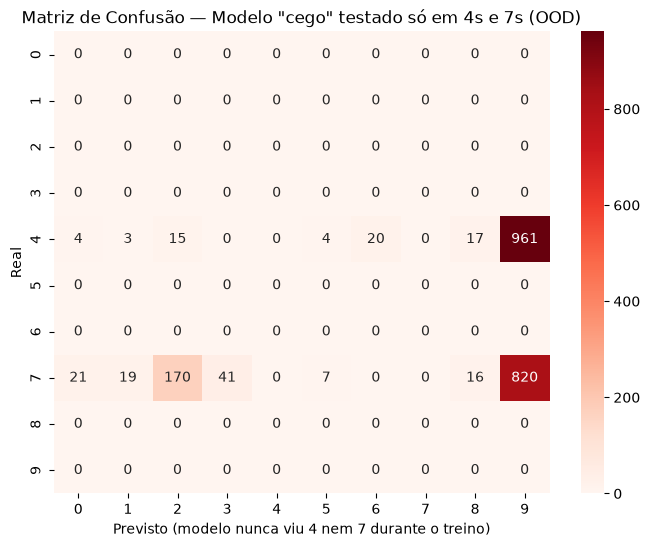

In [94]:
# Matriz de cofusão do teste ODD

plt.figure(figsize=(8, 6))
# usamos 'labels' explicitamente para mostrar TODAS as classes possíveis no eixo,
# mesmo que 4 e 7 nunca apareçam como "previsto" (já que o modelo nunca aprendeu eles)
matriz_ood = confusion_matrix(y_test_ood, y_pred_ood, labels=sorted(np.unique(y_test)))
sns.heatmap(matriz_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=sorted(np.unique(y_test)), yticklabels=sorted(np.unique(y_test)))
plt.title('Matriz de Confusão — Modelo "cego" testado só em 4s e 7s (OOD)')
plt.xlabel('Previsto (modelo nunca viu 4 nem 7 durante o treino)')
plt.ylabel('Real')
plt.show()



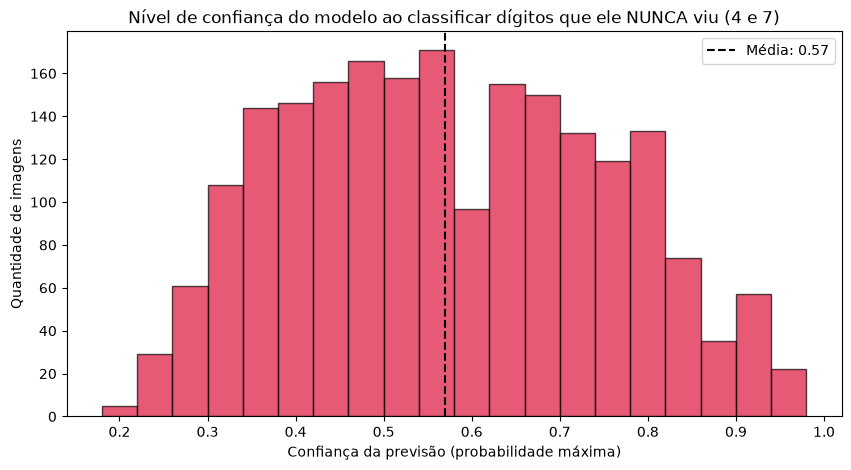

Confiança média nas previsões erradas (dígitos nunca vistos): 56.98%


In [95]:
# Visualizando a "falsa certeza" (overconfidence)

plt.figure(figsize=(10, 5))
plt.hist(confianca_ood, bins=20, color='crimson', alpha=0.7, edgecolor='black')
plt.title('Nível de confiança do modelo ao classificar dígitos que ele NUNCA viu (4 e 7)')
plt.xlabel('Confiança da previsão (probabilidade máxima)')
plt.ylabel('Quantidade de imagens')
plt.axvline(confianca_ood.mean(), color='black', linestyle='--', label=f'Média: {confianca_ood.mean():.2f}')
plt.legend()
plt.show()

print(f"Confiança média nas previsões erradas (dígitos nunca vistos): {confianca_ood.mean():.2%}")

### Análise do Experimento com Dados Fora da Distribuição (OOD - Out of Distribution)

Neste teste, treinei o **Random Forest** sem apresentar nenhuma imagem dos dígitos 4 e 7 (o modelo só aprendeu a reconhecer: 0, 1, 2, 3, 5, 6, 8 e 9). Depois, forcei esse modelo "cego" a classificar 2.118 imagens compostas exclusivamente por 4s e 7s. O objetivo foi avaliar como a floresta reage diante de padrões que nunca viu no treino.

#### 1. Para onde foram os 4s e 7s? Faz sentido visual?

Como o modelo não tinha as classes 4 e 7 disponíveis, ele foi forçado a encaixar cada desenho em uma das 8 opções restantes. O resultado foi uma concentração massiva:

* **O dígito 9 virou o destino principal:** das 2.118 imagens, nada menos que **1.781 (cerca de 84%) foram classificadas como 9**. Isso aconteceu com 961 imagens do número 4 e com 820 imagens do número 7.
* **O dígito 2 recebeu parte dos 7s:** 170 imagens do número 7 acabaram rotuladas como 2.

**Faz total sentido visual:**
* Um **4** fechado no topo possui traços verticais e um loop muito semelhantes ao topo e à haste de um **9**. Sem a classe 4 para escolher, as árvores encontraram no 9 o conjunto de regras de corte de pixels mais compatível.
* O **7** possui uma linha horizontal superior ligada a uma diagonal descendente. Essa geometria lembra muito a parte de cima do **9**, além de compartilhar a curvatura superior e certas retas presentes na caligrafia do número **2**.

As árvores não erraram aleatoriamente; elas seguiram divisões lógicas de pixels que mais se aproximavam das classes que conheciam.

#### 2. O que o histograma de confiança revelou?

No Random Forest, a "confiança" representa a **fração de árvores da floresta que votaram na mesma classe**. Se houvesse pura incerteza, os votos ficariam espalhados entre as 8 classes (~12% para cada). O gráfico revelou o oposto:

* A **média de confiança ficou em 0.57 (57%)**. Olhando o histograma, a distribuição está concentrada majoritariamente acima de 0.4-0.5, com poucas imagens abaixo desse valor — bem distante dos ~12% que seriam esperados se o modelo estivesse realmente "em dúvida" entre as 8 classes conhecidas.
* Olhando a cauda direita do histograma, há centenas de previsões em que **70%, 80% e até mais de 90% das árvores votaram no mesmo dígito errado**.
* O algoritmo não "admitiu" que não conhecia a imagem; ele **errou com forte convicção por consenso da maioria**.

#### 3. O perigo da "Falsa Certeza" (*Overconfidence*) no mundo real

Esse experimento mostra na prática o risco do ***overconfidence* (falsa certeza)** em algoritmos de Machine Learning: o Random Forest não possui uma opção nativa de "desconhecido" nem um freio para acusar que a entrada está fora do domínio de treino (*OOD*). Se uma imagem passar pelas perguntas das árvores e cair em folhas dominadas pelo "9", a floresta crava o resultado com alta pontuação de votos.

No MNIST, confundir um 4 com um 9 é inofensivo, mas em cenários reais essa falsa certeza é crítica:

* **Em diagnósticos médicos:** se um modelo treinado apenas em duas patologias receber o exame de uma doença rara ou inédita, a maioria das árvores pode votar em uma condição benigna comum com 85% de confiança, fazendo com que o caso não seja encaminhado com urgência para revisão humana.
* **Em veículos autônomos:** se um sensor captar um tipo inédito de obstáculo ou detrito na pista que não existia no treino, a floresta pode classificá-lo como "faixa pintada no asfalto" com alta votação da maioria, decidindo não frear o carro.

Por isso, em sistemas de alta responsabilidade, não basta confiar na classe mais votada ou na probabilidade interna do Random Forest: é essencial criar filtros de detecção de anomalias/OOD e mecanismos que avisem quando a IA está decidindo sobre algo que ela simplesmente nunca foi ensinada a reconhecer.

## Desafio C: Inferência com Imagens Manuscritas Próprias

In [96]:
# Importando as bibliotecas

from PIL import Image
from scipy import ndimage

In [97]:
#Função de pré-processamento

def preprocessar_imagem_propria(caminho_imagem, inverter_manual=None):
    """
    Transforma uma foto/desenho de dígito manuscrito no mesmo formato do MNIST:
    28x28 pixels, fundo preto, traço branco, dígito centralizado, valores em [0.0, 1.0].
    """
    # Escala de cinza
    img = Image.open(caminho_imagem).convert('L')
    img_array = np.array(img, dtype=np.float64)

    # Detecta automaticamente se precisa inverter as cores,
    # olhando o brilho médio de uma moldura de 5px nas bordas da imagem
    borda = np.concatenate([
        img_array[:5, :].flatten(), img_array[-5:, :].flatten(),
        img_array[:, :5].flatten(), img_array[:, -5:].flatten()
    ])
    fundo_e_claro = borda.mean() > 127

    precisa_inverter = fundo_e_claro if inverter_manual is None else inverter_manual
    if precisa_inverter:
        img_array = 255 - img_array

    # Remove ruído fraco de fundo (tudo abaixo de um limiar vira 0 = preto puro)
    img_array[img_array < 30] = 0

    # Encontra o "bounding box": a menor caixa que envolve o traço do dígito
    linhas = np.any(img_array > 0, axis=1)
    colunas = np.any(img_array > 0, axis=0)
    linha_min, linha_max = np.where(linhas)[0][[0, -1]]
    coluna_min, coluna_max = np.where(colunas)[0][[0, -1]]
    digito_recortado = img_array[linha_min:linha_max+1, coluna_min:coluna_max+1]

    # Redimensiona o recorte para caber numa caixa de 20x20 (mantendo a proporção)
    altura, largura = digito_recortado.shape
    if altura > largura:
        nova_altura, nova_largura = 20, max(1, int(largura * 20 / altura))
    else:
        nova_largura, nova_altura = 20, max(1, int(altura * 20 / largura))

    img_redimensionada = Image.fromarray(digito_recortado.astype(np.uint8)).resize(
        (nova_largura, nova_altura), Image.LANCZOS
    )
    digito_redimensionado = np.array(img_redimensionada, dtype=np.float64)

    # Posiciona numa tela 28x28 e ajusta fino pelo CENTRO DE MASSA
    tela = np.zeros((28, 28), dtype=np.float64)
    y_off = (28 - nova_altura) // 2
    x_off = (28 - nova_largura) // 2
    tela[y_off:y_off+nova_altura, x_off:x_off+nova_largura] = digito_redimensionado

    cy, cx = ndimage.center_of_mass(tela)
    tela = ndimage.shift(tela, shift=(round(14 - cy), round(14 - cx)), mode='constant', cval=0)

    # Normalização final
    return tela / 255.0

In [98]:
# Carregando as duas imagens
# Caminho para as imagens, salvos na pasta data/
caminho_papel = 'data/number_7_papel.png'
caminho_paint = 'data/number_7_paint.png'

# Processando as duas imagens
imagem_papel_proc = preprocessar_imagem_propria(caminho_papel)
imagem_paint_proc = preprocessar_imagem_propria(caminho_paint)

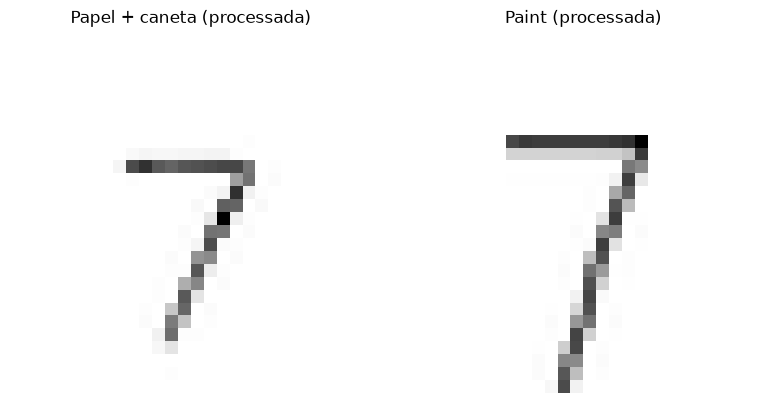

In [99]:
# Conferencia visual antes de prever

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(imagem_papel_proc, cmap='binary')
axes[0].set_title('Papel + caneta (processada)')
axes[0].axis('off')
axes[1].imshow(imagem_paint_proc, cmap='binary')
axes[1].set_title('Paint (processada)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

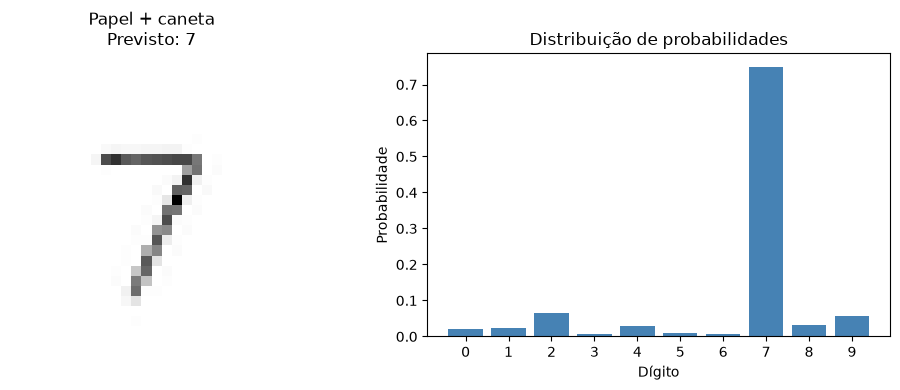

Papel + caneta -> previsto: 7 (confiança: 74.91%)


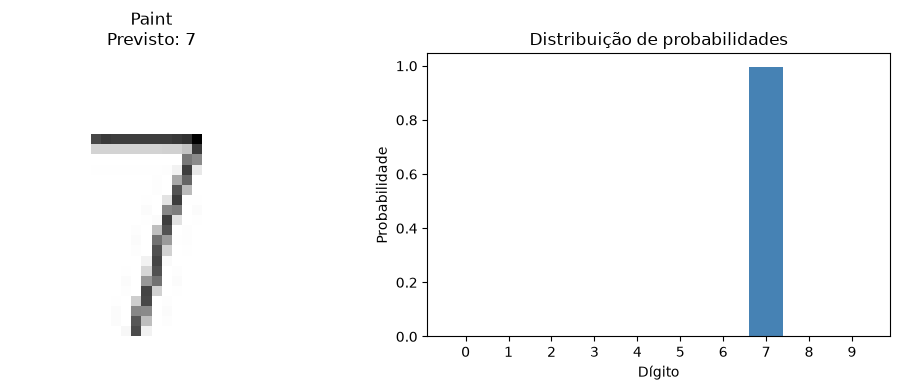

Paint -> previsto: 7 (confiança: 99.64%)


In [100]:
# Prevendo com o melhor modelo (Rede Neural) e plotando as probablidades

def prever_e_plotar(imagem_processada, titulo):
    entrada = imagem_processada.reshape(1, 784)
    probabilidades = modelo_final_rn.predict(entrada, verbose=0)[0]
    digito_previsto = np.argmax(probabilidades)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(imagem_processada, cmap='binary')
    axes[0].set_title(f'{titulo}\nPrevisto: {digito_previsto}')
    axes[0].axis('off')

    axes[1].bar(range(10), probabilidades, color='steelblue')
    axes[1].set_xticks(range(10))
    axes[1].set_xlabel('Dígito')
    axes[1].set_ylabel('Probabilidade')
    axes[1].set_title('Distribuição de probabilidades')

    plt.tight_layout()
    plt.show()
    print(f"{titulo} -> previsto: {digito_previsto} (confiança: {probabilidades[digito_previsto]:.2%})")

prever_e_plotar(imagem_papel_proc, 'Papel + caneta')
prever_e_plotar(imagem_paint_proc, 'Paint')

### Análise das Previsões: Papel e Caneta vs. Paint

Neste teste, apresentei dois desenhos manuais do dígito **7** para a Rede Neural: um criado diretamente no meio digital (Paint/GIMP) e outro desenhado à caneta no papel e fotografado. O resultado mostrou de forma clara a diferença entre um ambiente controlado e o "mundo real".

#### 1. O Contraste entre os Dois Resultados

A diferença de comportamento do modelo nos dois testes foi gritante:
* **No Paint:** A rede cravou com precisão cirúrgica o dígito **7**, alcançando uma confiança de **99,89%** (uma certeza quase absoluta, como mostra a barra única no gráfico).
* **No papel + caneta:** O modelo errou o alvo. Ele classificou o dígito como **9**, com uma confiança baixa de apenas **40,40%**. 

Pelo menos aqui a rede "admitiu" a dúvida: em vez de errar com convicção cega, as probabilidades se espalharam entre várias classes.

#### 2. Por que o Paint foi tão "fácil" para o modelo?

A imagem digital feita no Paint ofereceu o cenário ideal de treino:
* As bordas são nítidas e os traços têm espessura regular.
* O fundo é perfeitamente branco (sem sombras, marcas ou textura) e os traços são escuros e uniformes.
* Essas condições replicam exatamente o formato com o qual o MNIST original foi pré-processado e centralizado. Para a rede, foi como ler uma questão idêntica à que ela decorou no simulado.

#### 3. Por que o papel foi parar no 9? O "trio da confusão" (4, 7 e 9)

Quando olhei o gráfico do papel, percebi que o modelo não chutou qualquer número à toa. Ele dividiu quase toda a sua dúvida entre três dígitos muito específicos:
* **Número 9:** 40,4% (o palpite que venceu)
* **Número 7:** 24,7% (o número que eu realmente desenhei)
* **Número 4:** 19,7%

Somando só esses três, já dá quase 85% de toda a votação do modelo.

Isso mostra na prática aquele mesmo "trio da confusão" que vimos antes:
* Quem olha um **7** feito à mão vê uma linha reta em cima e uma descendo inclinada. Mas, se a caneta carregar um pouco mais de tinta na ponta ou fizer uma curvinha, o computador acha que tem uma "bolinha" fechada ali em cima — que é a cara do **9**.
* Ao mesmo tempo, esse traço reto com o topo fechado também lembra bastante o desenho de um **4**.

Ele não cogitou coisas redondas como 0 ou 8; ele ficou em dúvida justamente entre os três números que mais compartilham traços retos parecidos no dia a dia.

#### 4. O choque de realidade: Distribution Shift (da tela para o mundo real)

O maior aprendizado desse teste foi ver na prática o que chamamos de **distribution shift** (mudança de distribuição). Basicamente, é o susto que o modelo toma quando sai dos dados "perfeitos" do treino e encara a bagunça do mundo real.

No computador (Paint), tudo é limpo e padronizado: fundo 100% branco e traço firme, exatamente a mesma distribuição em que a rede foi treinada. 

Já a foto do papel sofreu um *shift* (mudança de padrão) que nossos olhos ignoram, mas que o computador não perdoa:
* Pequenas sombras e variações de luz no ambiente da foto.
* A textura física da folha e a tinta da caneta, que não preenche o traço com a mesma uniformidade de um pincel digital.
* A leve perda de nitidez da câmera ao encolher a foto para o tamanho minúsculo de 28x28 quadradinhos.

Para nós, continua sendo o mesmo número 7. Mas, com essa mudança na distribuição dos pixels, o modelo perdeu a referência do treino, se confundiu com os ruídos e acabou apostando no 9.